# Installation and Setup
The cells below set up the python environment that is required to run the other cells. Please run these using a dedicated virtual environment. 

## Installation
In the two cells below, the required libraries for the application are installed.

In [1]:
# necessary for working on the underlying code in tempo-embeddings
# TODO: remove before workshop
%load_ext autoreload

In [2]:
import sys
sys.path.append('../') # adding the main dir to pythonpath
%pip uninstall -y tempo_embeddings
%pip install -e ..
%pip install ipywidgets

Found existing installation: tempo_embeddings 0.0.1
Uninstalling tempo_embeddings-0.0.1:
  Successfully uninstalled tempo_embeddings-0.0.1
Note: you may need to restart the kernel to use updated packages.
Obtaining file:///Users/Stiph002/Projects/tempo-embeddings
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for tempo_embeddings (pyproject.toml) ... done
  Created wheel for tempo_embeddings: filename=tempo_embeddings-0.0.1-0.editable-py3-none-any.whl size=9825 sha256=4b399f812f12efd4d174f3c5286a65ad1ad5ef466581b314e6d507df2a9ccd2f
  Stored in directory: /private/var/folders/py/wbsw504x3fq0b3p3lprpf8d80000gn/T/pip-ephem-wheel-cache-zfliq2by/wheels/0e/b2/2d/7abe4505904013894f2ea83d0338f6d812a52569c8e03deaa6
Successfully built tempo_embeddings

[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice

## Data Pre-selection

### Select dataset and set API key
Here, you can select the server from which you want to access the database. The default is the 'UU' server, but if that gives you problems down the line, we have a backup server on ResearchCloud. 

In [2]:
from ipywidgets import widgets

from tempo_embeddings.settings import WEAVIATE_SERVERS

## Setting default host to the UU server
default_host = WEAVIATE_SERVERS[0][1]
## Hardcoded Weaviate API Key: TODO: get this from a secure place
weaviate_api_key = ""

host_selector = widgets.Dropdown(
    options=WEAVIATE_SERVERS, value=default_host, description="DB Server:"
)
host_selector

Dropdown(description='DB Server:', options=(('UU', ('semantics-of-sustainability.hum.uu.nl', 443, True)), ('Re…

### Initialize WeaviateDatabaseManager
After selecting a server, you can initialize your local Weaviate database.

In [3]:
from tempo_embeddings.embeddings.weaviate_database import WeaviateDatabaseManager
from tempo_embeddings.settings import DEFAULT_LANGUAGE_MODEL

host, port, secure = host_selector.value

db = WeaviateDatabaseManager.from_args(
    model_name=DEFAULT_LANGUAGE_MODEL,
    http_host=host,
    http_port=port,
    http_secure=secure,
    api_key=weaviate_api_key,
)

/Users/Stiph002/.pyenv/versions/3.11.11/envs/tempo-embeddings/lib/python3.11/site-packages/umap/__init__.py:9: ImportWarning: Tensorflow not installed; ParametricUMAP will be unavailable
  warn(
/Users/Stiph002/.pyenv/versions/3.11.11/envs/tempo-embeddings/lib/python3.11/site-packages/weaviate/warnings.py:133: DeprecationWarning: Dep005: You are using weaviate-client version 4.6.7. The latest version is 4.11.1.
            Consider upgrading to the latest version. See https://weaviate.io/developers/weaviate/client-libraries/python for details.
  warnings.warn(


In [4]:
from ipywidgets import widgets

#  get a list of available collections from the Weaviate database (db)
available_collections = sorted(db.get_available_collections())

# Prepare collection / Corpus
The widget below allows you to choose a collection from the database. A 'collection' is a Weaviate object, and includes:
 - a collection of data objects (documents), in this case either newspaper articles or parliamentary speeches 
 - metadata about the data objects,
 - a schema that defines the structure of the objects and their properties,
 - a collection of *vectors*, i.e. numerical representations of the data objects

The term 'collection' is a Weaviate-specific term, whereas 'corpus' is more general. In this notebook, 'corpus' will be used to denote another type of collected data, i.e. a refined collection based on search words and their nearest neighbours.
 

In [6]:
#  select one or several collections to work with in the widget below
collection_selector = widgets.SelectMultiple(
    options=available_collections,
    value=["PeopleAndParliament"],
    description="Choose one or multiple collections:",
    disabled=False,
    layout={"width": "max-content"},
    rows=len(available_collections),
)
collection_selector

SelectMultiple(description='Choose one or multiple collections:', index=(3,), layout=Layout(width='max-content…

#### Enter search terms
Below this cell you can enter search terms which will be used to generate a corpus of passages containing these search terms. Only passages from the selected collections that contain the search term(s) are part of the initial corpus.

In [7]:
text_widgets = [
    widgets.Text(description="Search Term:", value="duurzaam"),
    widgets.Text(
        description="Search Term:", value="milieu", placeholder="Enter a term"
    ),
    widgets.Text(description="Search Term:", placeholder="Enter a term"),
    widgets.Text(description="Search Term:", placeholder="Enter a term"),
    widgets.Text(description="Search Term:", placeholder="Enter a term"),
]

widgets.VBox(text_widgets)

## Data Insights
Below you can gain some insight into the initial corpus. Specifically, you can see how many passages per search term there are.

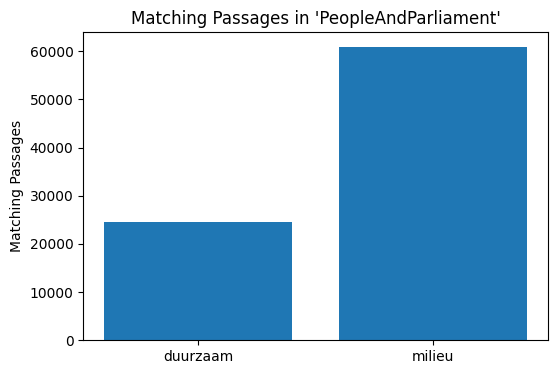

In [ ]:
import matplotlib.pyplot as plt

search_terms: list[str] = [
    widget.value.strip() for widget in text_widgets if widget.value
]
if not search_terms:
    raise RuntimeError("No seach terms provided.")

fig, axs = plt.subplots(
    len(collection_selector.value),
    sharey=True,
    figsize=(3 * len(search_terms), 4 * len(collection_selector.value)),
)
plt.subplots_adjust(hspace=0.5)  # Increase the height space between subplots

if len(collection_selector.value) == 1:
    axs = [axs]


for ax, collection in zip(axs, collection_selector.value):
    total_count = db.doc_frequency("", collection)

    ax.set_title(f"Matching Passages in '{collection}'")
    ax.set_ylabel("Matching Passages")

    term_freqs = [db.doc_frequency(term, collection) for term in search_terms]

    ax.bar(search_terms, term_freqs)

In [9]:
start = 1850
end = 2024

year_range = widgets.SelectionRangeSlider(
    options=[str(i) for i in range(start, end + 1)],
    index=(1950 - start, end - start),
    description="Years",
)
year_range

SelectionRangeSlider(description='Years', index=(100, 174), options=('1850', '1851', '1852', '1853', '1854', '…

The cells below generate a dataframe (a kind of table) with passage frequencies per collection per year and plot these.

In [ ]:
import pandas as pd
from tqdm import tqdm

doc_freqs = pd.DataFrame(
    columns=search_terms,
    index=pd.MultiIndex.from_product(
        (
            collection_selector.value,
            range(int(year_range.value[0]), int(year_range.value[1])),
        ),
        names=["collection", "year"],
    ),
)

for collection in tqdm(collection_selector.value, unit="collection"):
    for term in search_terms:
        term_freqs = db.doc_frequencies_per_year(
            term, collection, int(year_range.value[0]), int(year_range.value[1])
        )
        for year, freq in term_freqs.items():
            doc_freqs.at[(collection, year), term] = freq


100%|██████████| 1/1 [00:01<00:00,  1.04s/collection]


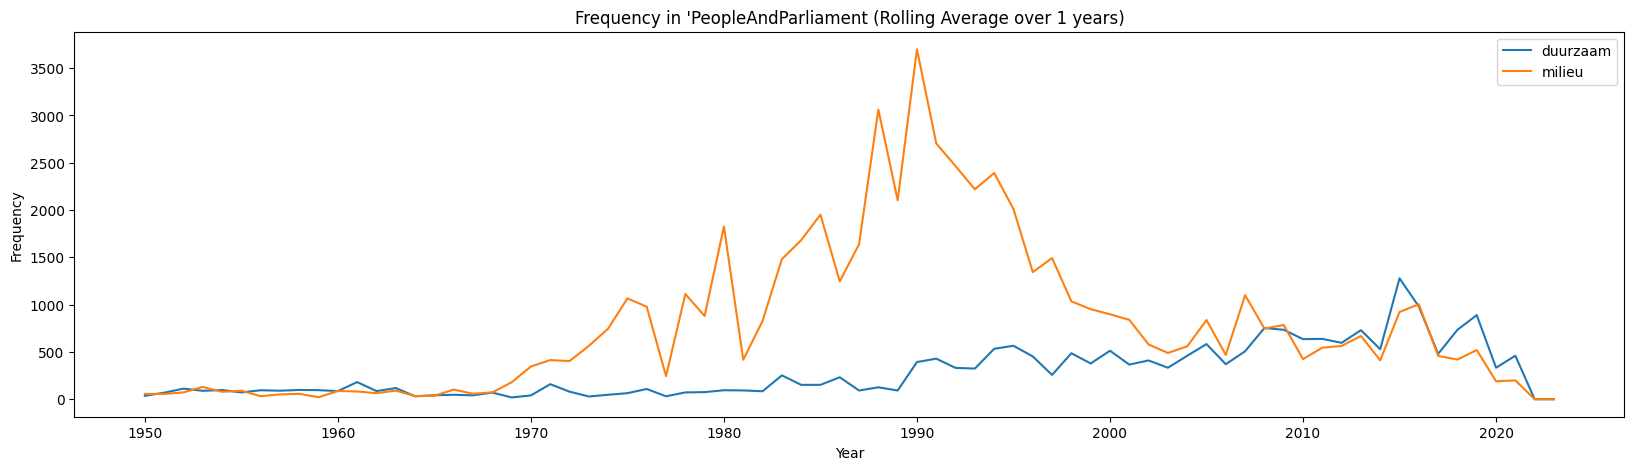

In [ ]:
window_size = 1 # number of years to average over

for collection in doc_freqs.index.get_level_values("collection").unique():
    doc_freqs.loc[collection].rolling(window_size).mean().plot(
        figsize=(20, 5),
        title=f"Frequency in '{collection} (Rolling Average over {window_size} years)",
        xlabel="Year",
        ylabel="Frequency",
    )

## Visualise the Embeddings

### Create the intial corpus from the collection and search terms
In the cell below, we create a **corpus** using the input from the widgets.

You start by creating an *initial* corpus for the scatterplot visualisation, which will contain only passages
 - from the selected collection (PeopleAndParliament or ANP or other), 
 - that contain (at least) one of the search terms
 - that were published somewhere within the date range that you have specified above

Currently, corpora are capped at 10000 documents, we use 5000 documents as a default value due to performance reasons: more documents would significantly slow down the application.

In [12]:
corpora = []
for collection in collection_selector.value:
    for term in search_terms:
        try:
            corpora.append(
                db.get_corpus(
                    collection,
                    [term],
                    year_from=year_range.value[0],
                    year_to=year_range.value[1],
                    include_embeddings=True,
                    limit=5000,
                )
            )
        except RuntimeError as e:
            print(
                f"Failed to retrieve data for term '{term}', collection '{collection}: {e}"
            )

### Expand Corpus with Close Passages

Now that the initial corpus has been created, this section can expand the corpus with *semantically close passages*, as determined by the language model. 

The passages above have been selected through the search term(s). The initial corpus will be complemented with passages that are semantically close to the passages in the initial corpus, regardless of whether or not they contain the search terms.

Here, further passages are added by retrieving similar passages, i.e. passages that have a cosine similarity that is lower than the threshold set by the user. The `distance` indicates the relative proximity required for such added text passages. This distance is expressed in *cosine similarity*, and can range from 0 (completely unrelated) to 1 (completely synonymous).

You start by setting the semantic distance.

In [13]:
distance_widget = widgets.FloatSlider(
    value=0.4, min=0, max=1, step=0.01, description="Distance Threshold"
)

distance_widget

FloatSlider(value=0.4, description='Distance Threshold', max=1.0, step=0.01)

Then, you set the maximum number of neighbours to include in the complemented corpus, where the nearest neighbours will be added first.

In [14]:
max_neighbours = widgets.BoundedIntText(
    description="Maximum number of neighbours per collection",
    value=1000,
    min=0,
    max=10000,
    step=100,
)
max_neighbours

BoundedIntText(value=1000, description='Maximum number of neighbours per collection', max=10000, step=100)

After setting the semantic distance and maximum number of neighbours, you run the code below to find the nearest neighbours for the complemented corpus and summarize these corpora of neighbours.

In [ ]:
from tqdm import tqdm

from tempo_embeddings.text.corpus import Corpus
from tempo_embeddings.text.passage import Passage
from tempo_embeddings.text.year_span import YearSpan

all_passages: set[Passage] = {
    passage for corpus in corpora for passage in corpus.passages
}

neighbours: dict[Corpus, Corpus] = {}
for collection in tqdm(corpora, unit="collection", desc="Getting Neighbours"):
    try:
        neighbours[collection] = db.neighbours(
            collection,
            k=max_neighbours.value,
            collections=collection_selector.value,
            distance=distance_widget.value,
            year_span=YearSpan(year_range.value[0], year_range.value[1]),
            exclude_passages=all_passages,
        )
    except RuntimeError as e:
        print(f"Error while retrieving collection '{collection}': {e}")

# Remove empty neighbours collections
neighbours = {
    collection: _neighbours
    for collection, _neighbours in neighbours.items()
    if len(_neighbours) > 0
}

# provide a summary of the corpora and how many neighbours were found
try:
    label_length: int = max(len(collection.label) for collection in corpora)
except ValueError as e:
    raise RuntimeError("No corpora have been loaded.") from e

print(
    f"\n{'Collection Label'.ljust(label_length)}\tSize\tNeighbours with Distance < {distance_widget.value}"
)
for collection in corpora:
    print(
        f"{collection.label.ljust(label_length)}\t{len(collection)}\t{len(neighbours[collection])}"
    )

Getting Neighbours: 100%|██████████| 2/2 [00:13<00:00,  6.50s/collection]


Collection Label               	Size	Neighbours with Distance < 0.4
PeopleAndParliament: 'duurzaam'	3059	1000
PeopleAndParliament: 'milieu'  	2405	1000


### Merge Collections

The different parts retrieved in the above steps are merged into a single `Corpus` object, containing both the initial corpus, which contains all the passages that contain (one of the) the search term(s) as well as the set amount of neighbours per search term. This complemented corpus will be used to create the final visualisation.

In [16]:
from tempo_embeddings.text.corpus import Corpus

subcorpora = corpora + (list(neighbours.values()) if neighbours else [])

merged_corpus = sum(subcorpora, Corpus())
merged_corpus.label = "Initial Corpora plus Neighbours"

## Plot Corpus

This is the main entry point for investigating the corpus.
Each dot in the graph represents a single passage. Hover over a point to see its content and its metadata.

The contained text passages are plotted in a 2-dimensional plot. 
The plot furthermore provides interactive widgets to filter the data based on categorical (e.g. `source`) and continuous data (e.g. year range).

The Lasso tool allows for the selection arbitrary points by drawing a shape around the points of interest.
If no points are selected, all visible points are taken into account for the actions performed by the buttons:

- The *Cluster* button divides the selected points into groups of similar (hence close) text passages. It creates a new plot in a new tab; the initial data remains accessible by switching back to the first tab. The new tab supports the same operations again.
- The *Top Words* button outputs the most significant words of the selected points.
- The *Export* button writes the selected points to a CSV file.
- The *Plot by Field* button create a plot with relative frequencies for the selected data, based on a specific metadata field

In [ ]:
try:
    merged_corpus.compress_embeddings()  # Compute a 2D representation of the embeddings
except ValueError as e:
    print(
        "Could not compute 2D representation of the embeddings, probably because the corpus is empty."
    )
    raise e

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## Add Stopwords

Enter more words to be filtered out when computing the top words in the scatter plot.

This is **not updated dynamically**; re-run the subsequent cells after modifying the stopword list below.

In [18]:
stopwords_widget = widgets.Textarea(
    placeholder="Enter additional stopwords, one per line",
    description="Additional Stopwords",
    rows=10,
)
stopwords_widget

Textarea(value='', description='Additional Stopwords', placeholder='Enter additional stopwords, one per line',…

In [ ]:
from tempo_embeddings.settings import STOPWORDS
from tempo_embeddings.text.keyword_extractor import KeywordExtractor

# Generate a `KeywordExtractor` instance to extract keywords from the corpus

stopwords: set[str] = (
    STOPWORDS
    | set(search_terms)
    | {word.strip() for word in stopwords_widget.value.split("\n") if word.strip()}
)
keyword_extractor = KeywordExtractor(merged_corpus, exclude_words=stopwords).fit()

/Users/Stiph002/.pyenv/versions/3.11.11/envs/tempo-embeddings/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


### Filter fields: 
I think this is useless for the workshop <==TODO: figure out what to do with this>

In [ ]:
people_and_parliament_filter_fields = [
    "chamber",
    "label",
    "collection",
    "debate_title",
    "label",
    "party_id",
    "role",
    "speaker",
    "topic",
]

all_fields = people_and_parliament_filter_fields + list(
    people_and_parliament_filter_fields
)
filter_fields = widgets.TagsInput(
    allowed_tags=["label"] + list(merged_corpus.metadata_fields()),
    value=[
        field
        for field in people_and_parliament_filter_fields
        if field == "label" or field in merged_corpus.metadata_fields()
    ],
)

widgets.HBox(
    [
        widgets.Label(
            "Fields to create filters for (if applicable per selection). Click to remove or add more fields."
        ),
        filter_fields,
    ]
)

In [22]:
from tempo_embeddings.visualization.jscatter import JScatterContainer

visualizer = JScatterContainer(
    subcorpora,
    keyword_extractor=keyword_extractor,
    categorical_fields=filter_fields.value,
)
visualizer.visualize()

# Quick Access
Below you can quickly tune the parameters of the application and generate a new visualisation. You will start by selecting the collection(s) you want to work with, and then fill out the other parameters in the cell below. This will result in a new visualisation (waiting time: ...?)

In [5]:
#  select one or several collections to work with in the widget below
collection_selector = widgets.SelectMultiple(
    options=available_collections,
    value=["PeopleAndParliament"],
    description="Choose one or multiple collections:",
    disabled=False,
    layout={"width": "max-content"},
    rows=len(available_collections),
)
collection_selector

SelectMultiple(description='Choose one or multiple collections:', index=(3,), layout=Layout(width='max-content…

In [6]:
collections = list(collection_selector.value)  # these save the selection made in the cell above
search_terms = ['milieu', 'duurzaamheid']
year_range = (1800, 2024)
distance_threshold = 0.4
max_original_documents = 3000
max_neighbours = 1000
stopwords = ['mijnheer', 'mevrouw']
filter_fields = []
count_frequencies = False   # set to True to count the frequencies of the search terms in the documents, will add to the computing costs


In [7]:
from tempo_embeddings.utils import compile_new_visualiser

compile_new_visualiser(db, collections, search_terms, year_range, distance_threshold, max_original_documents, max_neighbours, stopwords, count_frequencies)

/Users/Stiph002/.pyenv/versions/3.11.11/envs/tempo-embeddings/lib/python3.11/site-packages/traitlets/__init__.py:28: DeprecationWarning: 
            Sentinel is not a public part of the traitlets API.
            It was published by mistake, and may be removed in the future.
            
  warn(
Getting Neighbours: 100%|██████████| 2/2 [00:10<00:00,  5.10s/collection]
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.



Collection Label                   	Size	Neighbours with Distance < 0.4
PeopleAndParliament: 'milieu'      	1551	1000
PeopleAndParliament: 'duurzaamheid'	1718	1000


/Users/Stiph002/.pyenv/versions/3.11.11/envs/tempo-embeddings/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
